<a href="https://colab.research.google.com/github/RobbieKing69/Mi-proyecto-devops/blob/main/Avance_del_proyecto_ADAA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exploración inicial del dataset

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

# Set the path to the file you'd like to load
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "blastchar/telco-customer-churn",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

# Primer vistazo a los registros del dataset
print("--- Primeros 5 registros ---")
print(df.head())
print("\--- ultimos 5 registros ---")
print(df.tail())
print("\--- Valores de las variables ---")
print(df.info())
print("\--- Datos generales del dataset ---")
print(df.describe())
num_filas, num_columnas = df.shape
print("\--- Dimenciones del dataset ---")
print(f"Número de filas (registros): {num_filas}")
print(f"Número de columnas (variables): {num_columnas}\n")
resumen_inicial = pd.DataFrame({
    'Tipo_Dato': df.dtypes,
    'Valores_Faltantes': df.isnull().sum(),
    'Porcentaje_Faltantes (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Valores_Unicos': df.nunique()
})

print("--- RESUMEN DE VARIABLES ---")
print(resumen_inicial)

print(f"\nTotal de registros duplicados exactos: {df.duplicated().sum()}")

<>:24: SyntaxWarning: invalid escape sequence '\-'
<>:26: SyntaxWarning: invalid escape sequence '\-'
<>:28: SyntaxWarning: invalid escape sequence '\-'
<>:31: SyntaxWarning: invalid escape sequence '\-'
<>:24: SyntaxWarning: invalid escape sequence '\-'
<>:26: SyntaxWarning: invalid escape sequence '\-'
<>:28: SyntaxWarning: invalid escape sequence '\-'
<>:31: SyntaxWarning: invalid escape sequence '\-'
/tmp/ipykernel_2148/1377804399.py:24: SyntaxWarning: invalid escape sequence '\-'
  print("\--- ultimos 5 registros ---")
/tmp/ipykernel_2148/1377804399.py:26: SyntaxWarning: invalid escape sequence '\-'
  print("\--- Valores de las variables ---")
/tmp/ipykernel_2148/1377804399.py:28: SyntaxWarning: invalid escape sequence '\-'
  print("\--- Datos generales del dataset ---")
/tmp/ipykernel_2148/1377804399.py:31: SyntaxWarning: invalid escape sequence '\-'
  print("\--- Dimenciones del dataset ---")


Using Colab cache for faster access to the 'telco-customer-churn' dataset.
--- Primeros 5 registros ---
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic

Limpieza de datos

Convertimos TotalCharges a numerico:

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip(), errors='coerce')

In [ ]:
resumen_inicial = pd.DataFrame({
    'Tipo_Dato': df.dtypes,
    'Valores_Faltantes': df.isnull().sum(),
    'Porcentaje_Faltantes (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Valores_Unicos': df.nunique()
})

print("--- RESUMEN DE VARIABLES ---")
print(resumen_inicial)

--- RESUMEN DE VARIABLES ---
                 Tipo_Dato  Valores_Faltantes  Porcentaje_Faltantes (%)  \
customerID          object                  0                      0.00   
gender              object                  0                      0.00   
SeniorCitizen        int64                  0                      0.00   
Partner             object                  0                      0.00   
Dependents          object                  0                      0.00   
tenure               int64                  0                      0.00   
PhoneService        object                  0                      0.00   
MultipleLines       object                  0                      0.00   
InternetService     object                  0                      0.00   
OnlineSecurity      object                  0                      0.00   
OnlineBackup        object                  0                      0.00   
DeviceProtection    object                  0                      0.00

Distribución de la variable objetivo (Churn)

In [ ]:
resumen_churn = pd.DataFrame({
    'Conteo': df['Churn'].value_counts(),
    'Porcentaje (%)': (df['Churn'].value_counts(normalize=True) * 100).round(2)
})
print(resumen_churn)

       Conteo  Porcentaje (%)
Churn                        
No       5174           73.46
Yes      1869           26.54


In [ ]:
espacios_vacios = (df['TotalCharges'] == " ").sum()
print(f"Registros con espacio en blanco: {espacios_vacios}")

Registros con espacio en blanco: 0


Verificamos Categorías inconsistentes, Variables con una sola categoría o demasiadas categorías, Rangos imposibles y Fuga de información

In [ ]:
import numpy as np

# 1. Categorías inconsistentes, espacios extra y valores unicos por variable categórica
print("--- 1. ANÁLISIS DE VARIABLES CATEGÓRICAS Y POSIBLES INCONSISTENCIAS ---")
columnas_categoricas = df.select_dtypes(include=['object']).columns

for col in columnas_categoricas:
    valores_unicos = df[col].unique()
    num_unicos = len(valores_unicos)
    print(f"\nVariable: '{col}' (Total valores únicos: {num_unicos})")
    print(f"Valores: {valores_unicos[:10]}") # Muestra los primeros 10

    # Detección de posibles categorías redundantes por espacios en blanco al inicio/final
    if df[col].dtype == 'object':
        tiene_espacios = df[col].apply(lambda x: isinstance(x, str) and (x != x.strip())).any()
        if tiene_espacios:
            print(f"  --> [ALERTA] '{col}' contiene valores con espacios iniciales o finales de más.")

# 2. Variables con una sola categoría o demasiadas categorías (ej. ID)
print("\n--- 2. VARIABLES CON 1 SOLA CATEGORÍA O DEMASIADAS CATEGORÍAS ---")
for col in df.columns:
    unicos = df[col].nunique()
    if unicos == 1:
        print(f"[ALERTA] La variable '{col}' tiene una sola categoría. (Candidata a eliminar)")
    elif unicos == len(df):
        print(f"[ALERTA] La variable '{col}' es un identificador único. (Candidata a eliminar)")

# 3. Rangos imposibles o poco razonables en variables numéricas
print("\n--- 3. RANGOS Y VALORES MÍNIMOS/MÁXIMOS EN VARIABLES NUMÉRICAS ---")

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
resumen_rangos = df[num_cols].agg(['min', 'max', lambda x: (x < 0).sum()]).rename(index={'<lambda>': 'valores_negativos'})
print(resumen_rangos)

# 4. Verificación de Fuga de Información (Information Leakage)
print("\n--- 4. ANÁLISIS DE FUGA DE INFORMACIÓN ---")
# Calculamos la correlación/asociación directa o si alguna variable predice al 100% Churn
for col in df.columns:
    if col != 'Churn':
        crosstab = pd.crosstab(df[col], df['Churn'], normalize='index')
        # Si alguna categoría tiene 100% de Churn = Yes o 100% Churn = No con suficiente muestra
        fuga = crosstab[(crosstab['Yes'] == 1.0) | (crosstab['No'] == 1.0)]
        if not fuga.empty:
            print(f"[ALERTA] Posible fuga en '{col}': determina el abandono al 100% en subgrupos.")

--- 1. ANÁLISIS DE VARIABLES CATEGÓRICAS Y POSIBLES INCONSISTENCIAS ---

Variable: 'customerID' (Total valores únicos: 7043)
Valores: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' '7795-CFOCW' '9237-HQITU'
 '9305-CDSKC' '1452-KIOVK' '6713-OKOMC' '7892-POOKP' '6388-TABGU']

Variable: 'gender' (Total valores únicos: 2)
Valores: ['Female' 'Male']

Variable: 'Partner' (Total valores únicos: 2)
Valores: ['Yes' 'No']

Variable: 'Dependents' (Total valores únicos: 2)
Valores: ['No' 'Yes']

Variable: 'PhoneService' (Total valores únicos: 2)
Valores: ['No' 'Yes']

Variable: 'MultipleLines' (Total valores únicos: 3)
Valores: ['No phone service' 'No' 'Yes']

Variable: 'InternetService' (Total valores únicos: 3)
Valores: ['DSL' 'Fiber optic' 'No']

Variable: 'OnlineSecurity' (Total valores únicos: 3)
Valores: ['No' 'Yes' 'No internet service']

Variable: 'OnlineBackup' (Total valores únicos: 3)
Valores: ['Yes' 'No' 'No internet service']

Variable: 'DeviceProtection' (Total valores únicos: 3)
Valores: [

Solucionaremos el problema de los valores faltantes en TotalCharges rellenandolos con la media. Y solucuonaremos los valores atipicos con

In [ ]:
mediana_total = df["TotalCharges"].median()
df["TotalCharges"].fillna(mediana_total, inplace=True)

/tmp/ipykernel_2148/796704751.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(mediana_total, inplace=True)


Visualización de valores atipicos

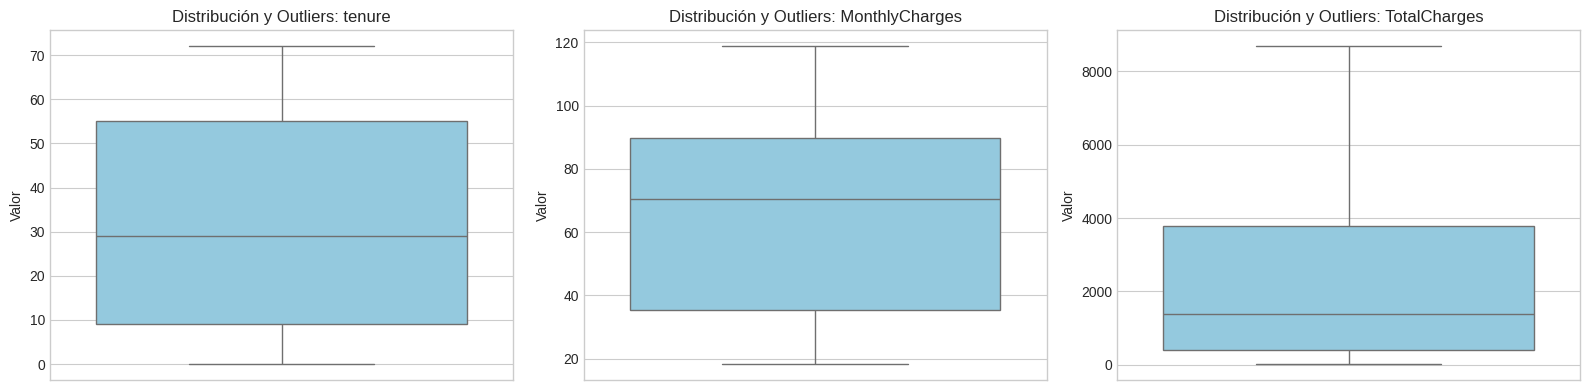

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución y Outliers: {col}', fontsize=12)
    axes[i].set_ylabel('Valor')

plt.tight_layout()
plt.show()

Analisis exploratorio de las variables

/tmp/ipykernel_2148/2202982169.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette=['#2b5c8f', '#d9534f'], ax=ax)


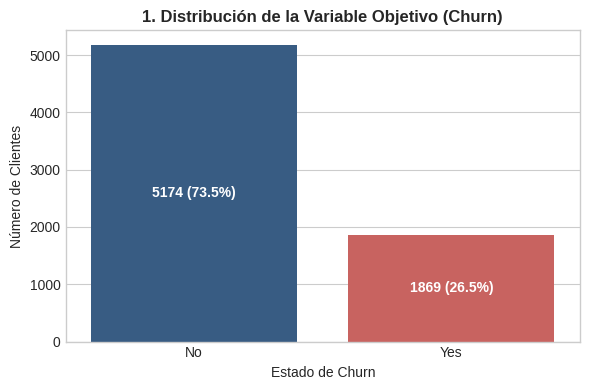

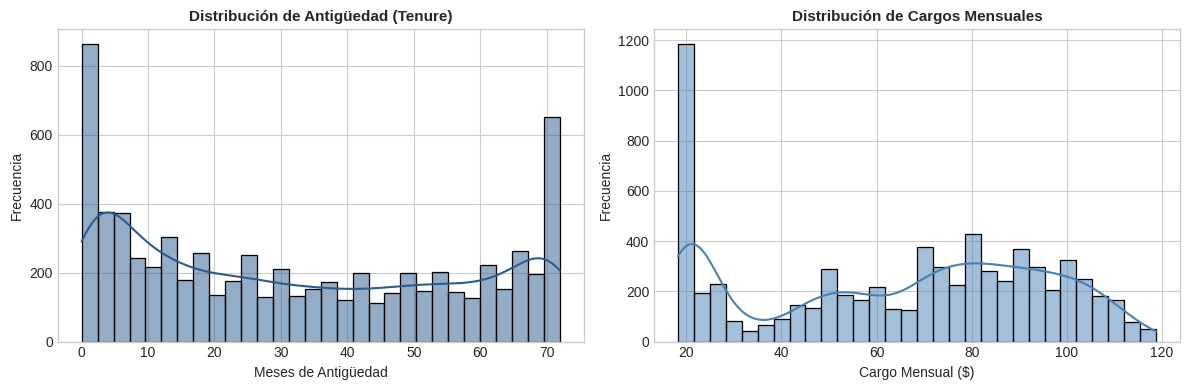

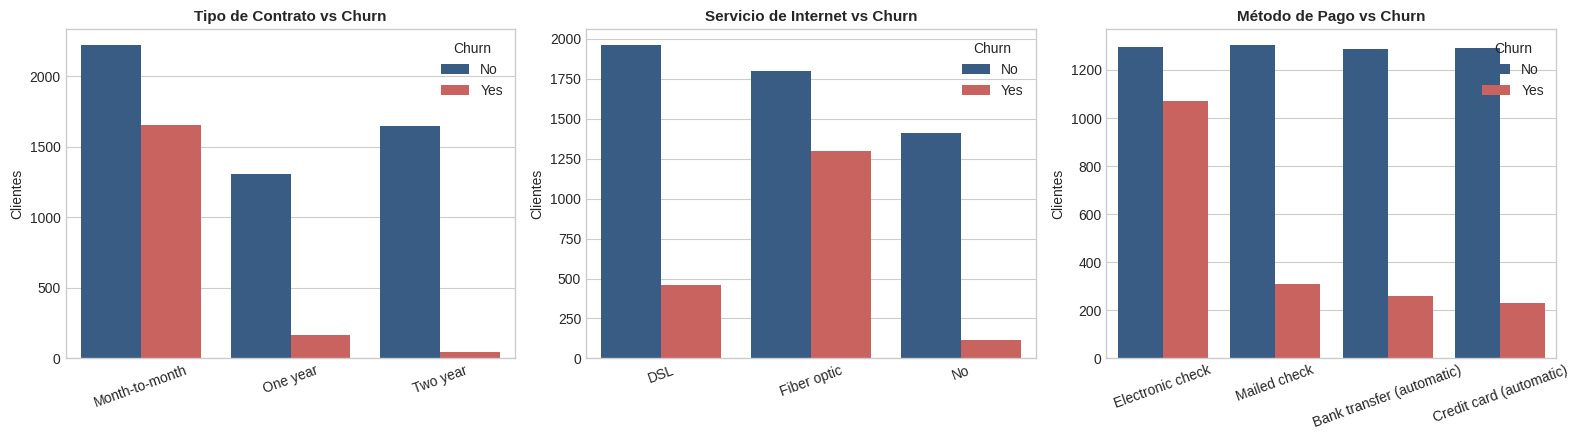

/tmp/ipykernel_2148/2202982169.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', palette=['#2b5c8f', '#d9534f'], ax=axes[0])
/tmp/ipykernel_2148/2202982169.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#2b5c8f', '#d9534f'], ax=axes[1])


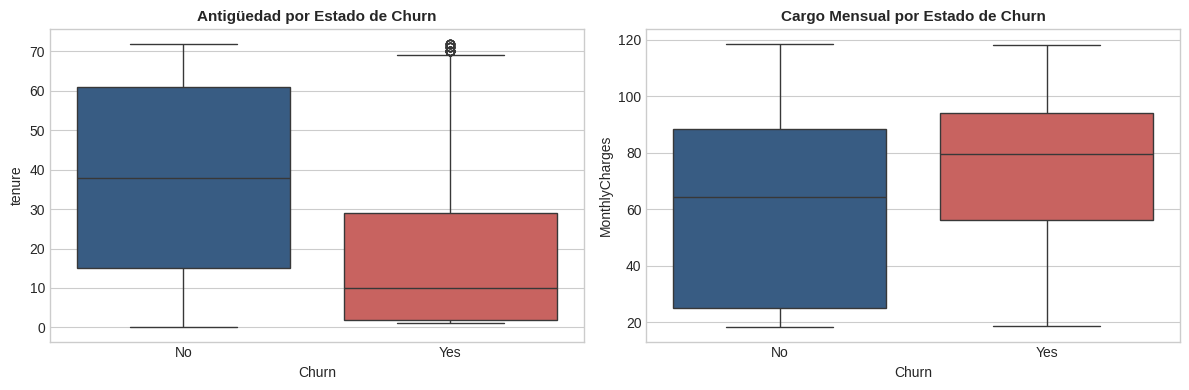

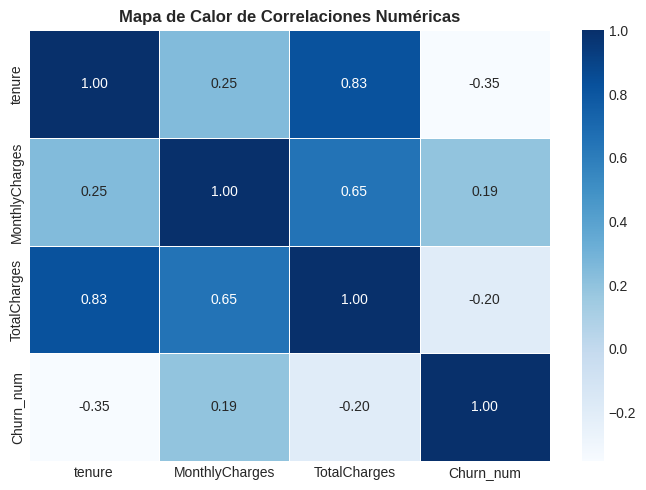

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuración de estilo
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 10

# ---------------------------------------------------------
# 1. Distribución de la Variable Objetivo (Churn)
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette=['#2b5c8f', '#d9534f'], ax=ax)
ax.set_title('1. Distribución de la Variable Objetivo (Churn)', fontsize=12, fontweight='bold')
ax.set_xlabel('Estado de Churn')
ax.set_ylabel('Número de Clientes')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. Distribución de Variables Numéricas (Tenure y MonthlyCharges)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['tenure'], kde=True, ax=axes[0], color='#2b5c8f', bins=30)
axes[0].set_title('Distribución de Antigüedad (Tenure)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Meses de Antigüedad')
axes[0].set_ylabel('Frecuencia')

sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[1], color='#4682b4', bins=30)
axes[1].set_title('Distribución de Cargos Mensuales', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Cargo Mensual ($)')
axes[1].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. Comparación de Variables Categóricas vs Churn (3 Variables Clave)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
cols_cat = ['Contract', 'InternetService', 'PaymentMethod']
titles = ['Tipo de Contrato vs Churn', 'Servicio de Internet vs Churn', 'Método de Pago vs Churn']

for i, col in enumerate(cols_cat):
    sns.countplot(data=df, x=col, hue='Churn', palette=['#2b5c8f', '#d9534f'], ax=axes[i])
    axes[i].set_title(titles[i], fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Clientes')
    axes[i].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. Relación entre Variables Numéricas y Churn (Boxplots)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x='Churn', y='tenure', palette=['#2b5c8f', '#d9534f'], ax=axes[0])
axes[0].set_title('Antigüedad por Estado de Churn', fontsize=11, fontweight='bold')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#2b5c8f', '#d9534f'], ax=axes[1])
axes[1].set_title('Cargo Mensual por Estado de Churn', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. Mapa de Calor de Correlación (Variables Numéricas)
# ---------------------------------------------------------
df['Churn_num'] = df['Churn'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(7, 5))
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_num']].corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones Numéricas', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Gráfico 1 (Variable Objetivo): Muestra una tasa de cancelación de ~26.5% frente al ~73.5% de permanencia, evidenciando un desbalance de clases moderado.

Gráfico 2 (Variables Numéricas): tenure presenta una distribución bimodal (alta concentración de clientes muy nuevos y clientes de larga estadía). MonthlyCharges muestra un pico en cargos bajos (~$20) correspondientes a servicios básicos de solo telefonía.

Gráfico 3 (Comparación de Categóricas): Los mayores índices de abandono se concentran en contratos mes a mes (Month-to-month), usuarios de fibra óptica (Fiber optic) y clientes que pagan mediante cheque electrónico (Electronic check).

Gráfico 4 (Boxplots de Antigüedad y Cargos): Los clientes que abandonan tienen una mediana de antigüedad significativamente menor (~10 meses) y cargos mensuales más altos en comparación con los clientes que permanecen.

Gráfico 5 (Matriz de Correlación): Existe una alta correlación positiva entre tenure y TotalCharges (0.83), y una relación negativa moderada entre tenure y Churn (-0.35), confirmando que a mayor antigüedad, menor es el riesgo de abandono.

Revisar el desvalanceo de las clases

Como vimos anteriormente en la graficación de distribución, en la variable objetivo existe un desvalance entre sus clases:
con una relación cercana a 3:1 a favor de los clientes que permanecen.

In [ ]:
print(resumen_churn)

       Conteo  Porcentaje (%)
Churn                        
No       5174           73.46
Yes      1869           26.54


Por qué una accuracy alta puede ser engañosa.

:Si un modelo predice que ningún cliente abandonará (clasificando el 100% de los datos como No), obtendría un 73.5% de Accuracy sin haber identificado a un solo cliente en riesgo. El desbalance oculta el fallo total en la detección de la clase de interés.
Qué métricas serán necesarias para evaluar adecuadamente el modelo.

:Recall: Mide la proporción de clientes que realmente abandonaron y que el modelo logró identificar.

Precision: Mide de los clientes identificados como "en riesgo", cuántos realmente abandonaron.

F1-Score: El promedio armónico entre Precision y Recall para medir el balance global.

ROC-AUC: Evalúa la capacidad del modelo para separar ambas clases a través de distintos umbrales de decisión.

Qué implicaciones tendría no detectar clientes que realmente abandonan.

:El costo operativo de no detectar el abandono es muy alto. Representa una gran pérdida de clientes y de ingresos recurrentes que generaban, perdiendo la oportunidad de aplicar campañas de retención preventivas.


Por qué, en esta fase, no es obligatorio aplicar técnicas de remuestreo.

:En una fase de línea base, es recomendable primero evaluar el desempeño directo de los modelos simples con sus datos originales y métricas ajustadas (como Recall y ROC-AUC). El remuestreo solo agregaria complejidad de mas y riesgo de sobreajuste si no se le aplica dentro de un pipeline bien hecha. Por esto, se propone como una técnica de mejora futura para la entrega final.

Separación de variables predictoras con la variable objetivo

In [ ]:
y = df['Churn'].map({'Yes': 1, 'No': 0})

# 2. Definir el conjunto de variables predictoras (X) excluyendo la variable objetivo y el ID
X = df.drop(columns=['customerID', 'Churn', 'Churn_num'])

print(f"Dimensiones del conjunto de características (X): {X.shape}")
print(f"Dimensiones del vector objetivo (y): {y.shape}")

Dimensiones del conjunto de características (X): (7043, 19)
Dimensiones del vector objetivo (y): (7043,)


Hacemos la divicion de datos. 70% de entrenamiento, 15% de validación y 15% de prueba


In [ ]:
from sklearn.model_selection import train_test_split

# 1. Primera partición: 70% Entrenamiento, 30% Temporal
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# 2. Segunda partición: Dividir el 30% temporal en 15% Validación y 15% Prueba
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Verificación de proporciones
print(f"Entrenamiento (70%): {X_train.shape[0]} muestras")
print(f"Validación    (15%): {X_val.shape[0]} muestras")
print(f"Prueba        (15%): {X_test.shape[0]} muestras")

Entrenamiento (70%): 4930 muestras
Validación    (15%): 1056 muestras
Prueba        (15%): 1057 muestras


In [ ]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Definición de grupos de variables (excluyendo customerID y Churn)
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod',
]

# 2. Pipeline para variables numéricas (Imputación por mediana + Escalamiento)
num_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]
)

# 3. Pipeline para variables categóricas (Imputación por moda + One-Hot Encoding)
cat_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        (
            'onehot',
            OneHotEncoder(
                drop='first', sparse_output=False, handle_unknown='ignore'
            ),
        ),
    ]
)

# 4. Ensamble del ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols),
    ],
    remainder='drop',  # Elimina variables no especificadas (como customerID si existiera)
)

# 5. Ajuste del preprocesador SOLO con los datos de entrenamiento (X_train)
X_train_prep = preprocessor.fit_transform(X_train)

# 6. Transformación de los conjuntos de Validación y Prueba (sin volver a ajustar/fit)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

print(
    '--- PREPROCESAMIENTO COMPLETADO CON ÉXITO Y LIBRE DE FUGA DE INFORMACIÓN ---'
)
print(f'Forma de X_train procesado: {X_train_prep.shape}')
print(f'Forma de X_val procesado:   {X_val_prep.shape}')
print(f'Forma de X_test procesado:  {X_test_prep.shape}')

--- PREPROCESAMIENTO COMPLETADO CON ÉXITO Y LIBRE DE FUGA DE INFORMACIÓN ---
Forma de X_train procesado: (4930, 30)
Forma de X_val procesado:   (1056, 30)
Forma de X_test procesado:  (1057, 30)


In [ ]:
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

# 1. Definir la lista de modelos a evaluar
# Usamos la misma semilla (random_state=42) para asegurar reproducibilidad
modelos = {
    'Baseline (Dummy Most Frequent)': DummyClassifier(
        strategy='most_frequent'
    ),
    'Regresión Logística': LogisticRegression(
        random_state=42, max_iter=1000
    ),
    'K-Nearest Neighbors (KNN)': KNeighborsClassifier(
        n_neighbors=5
    ),
}

resultados = []

# 2. Entrenar y evaluar cada modelo conectando el preprocesador del Punto 13
for nombre, modelo in modelos.items():
    # Creación del Pipeline completo: Preprocesamiento + Clasificador
    full_pipeline = Pipeline(
        steps=[('preprocessor', preprocessor), ('classifier', modelo)]
    )

    # Entrenamiento exclusivo con el conjunto de entrenamiento (X_train, y_train)
    full_pipeline.fit(X_train, y_train)

    # Predicciones sobre el conjunto de validación
    y_val_pred = full_pipeline.predict(X_val)

    # Probabilidades para ROC-AUC (solo si el modelo lo soporta)
    if hasattr(full_pipeline, 'predict_proba'):
        y_val_proba = full_pipeline.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_val_proba)
    else:
        auc = None

    # Cálculo de métricas sobre validación
    resultados.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_val, y_val_pred),
        'Precision': precision_score(
            y_val, y_val_pred, pos_label=1, zero_division=0
        ),
        'Recall': recall_score(y_val, y_val_pred, pos_label=1, zero_division=0),
        'F1-Score': f1_score(y_val, y_val_pred, pos_label=1, zero_division=0),
        'ROC-AUC': auc,
    })

# 3. Presentación de la tabla comparativa
df_resultados = pd.DataFrame(resultados)
print('--- TABLA COMPARATIVA EN EL CONJUNTO DE VALIDACIÓN ---')
print(df_resultados.to_string(index=False))

--- TABLA COMPARATIVA EN EL CONJUNTO DE VALIDACIÓN ---
                        Modelo  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Baseline (Dummy Most Frequent)  0.734848   0.000000 0.000000  0.000000 0.500000
           Regresión Logística  0.806818   0.648438 0.592857  0.619403 0.845322
     K-Nearest Neighbors (KNN)  0.768939   0.563830 0.567857  0.565836 0.792523


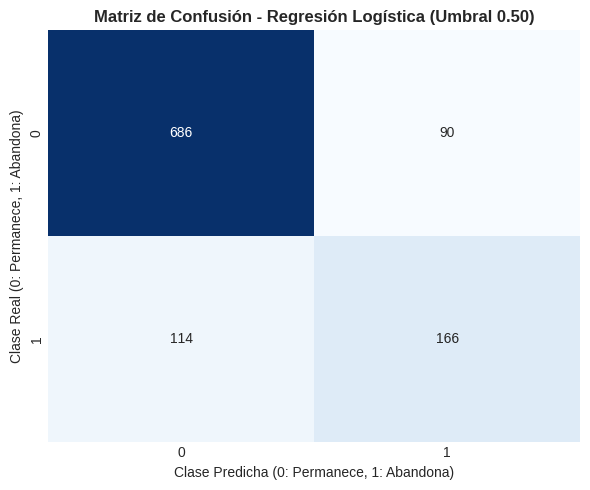

Verdaderos Negativos (TN): 686
Falsos Positivos (FP):     90
Falsos Negativos (FN):     114
Verdaderos Positivos (TP): 166

--- ANÁLISIS DE UMBRALES DE DECISIÓN ---
Umbral  Precision  Recall  F1-score                                                               Observación
  0.50     0.6484  0.5929    0.6194                                          Balance predeterminado estándar.
  0.35     0.5332  0.7464    0.6220 Prioriza capturar más clientes en riesgo a costa de más falsos positivos.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve

# Re-entrenamos / obtenemos la Regresión Logística dentro de su Pipeline completo
model_lr = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            LogisticRegression(random_state=42, max_iter=1000),
        ),
    ]
)
model_lr.fit(X_train, y_train)

# Probabilidades y predicciones con umbral 0.50 en validación
y_val_proba = model_lr.predict_proba(X_val)[:, 1]
y_val_pred_50 = (y_val_proba >= 0.50).astype(int)

# 1. Matriz de Confusión (Umbral 0.50)
cm = confusion_matrix(y_val, y_val_pred_50)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
ax.set_title(
    'Matriz de Confusión - Regresión Logística (Umbral 0.50)',
    fontsize=12,
    fontweight='bold',
)
ax.set_xlabel('Clase Predicha (0: Permanece, 1: Abandona)')
ax.set_ylabel('Clase Real (0: Permanece, 1: Abandona)')
plt.tight_layout()
plt.show()

print(f'Verdaderos Negativos (TN): {tn}')
print(f'Falsos Positivos (FP):     {fp}')
print(f'Falsos Negativos (FN):     {fn}')
print(f'Verdaderos Positivos (TP): {tp}\n')

# 2. Análisis del Umbral de Decisión (0.50 vs Umbral Alternativo, ej. 0.35)
umbrales_eval = [0.50, 0.35]
tabla_umbrales = []

for u in umbrales_eval:
    pred_u = (y_val_proba >= u).astype(int)
    prec = precision_score(y_val, pred_u, pos_label=1, zero_division=0)
    rec = recall_score(y_val, pred_u, pos_label=1, zero_division=0)
    f1 = f1_score(y_val, pred_u, pos_label=1, zero_division=0)

    obs = (
        'Balance predeterminado estándar.'
        if u == 0.50
        else 'Prioriza capturar más clientes en riesgo a costa de más falsos positivos.'
    )

    tabla_umbrales.append({
        'Umbral': f'{u:.2f}',
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-score': round(f1, 4),
        'Observación': obs,
    })

df_umbrales = pd.DataFrame(tabla_umbrales)
print('--- ANÁLISIS DE UMBRALES DE DECISIÓN ---')
print(df_umbrales.to_string(index=False))